In [1]:
# Outil de dessin vectoriel — clic gauche = point (relié par une droite), clic droit = terminer la ligne
# Backend : %matplotlib widget (ipympl) pour Cursor/VSCode, ou %matplotlib notebook en Jupyter classique

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# État du dessin : liste de polylignes (chaque polyligne = liste de points (x, y))
# current = points de la ligne en cours de dessin
draw_state = {
    "polylines": [],   # list of list of (x, y)
    "current": [],     # points de la ligne en cours
    "line_objects": [],  # Line2D déjà dessinées (pour les mettre à jour)
}

In [3]:
def redraw_drawing(ax, state):
    """Efface les lignes dessinées et redessine toutes les polylignes + la ligne en cours."""
    for art in state["line_objects"]:
        art.remove()
    state["line_objects"] = []
    for pts in state["polylines"]:
        if len(pts) < 2:
            continue
        xy = np.array(pts)
        (line,) = ax.plot(xy[:, 0], xy[:, 1], "b-", linewidth=2, picker=5)
        state["line_objects"].append(line)
    if len(state["current"]) >= 2:
        xy = np.array(state["current"])
        (line,) = ax.plot(xy[:, 0], xy[:, 1], "b-", linewidth=2, linestyle="--")
        state["line_objects"].append(line)
    elif len(state["current"]) == 1:
        (pt,) = ax.plot(
            state["current"][0][0], state["current"][0][1],
            "bo", markersize=6
        )
        state["line_objects"].append(pt)
    ax.figure.canvas.draw_idle()

In [4]:
def on_click(event, ax, state):
    """Clic gauche : ajouter un point (relié par une droite). Clic droit : terminer la ligne en cours."""
    if event.inaxes != ax or event.xdata is None:
        return
    x, y = event.xdata, event.ydata
    if event.button == 1:
        state["current"].append((float(x), float(y)))
    elif event.button == 3:
        if state["current"]:
            state["polylines"].append(state["current"].copy())
            state["current"] = []
    redraw_drawing(ax, state)

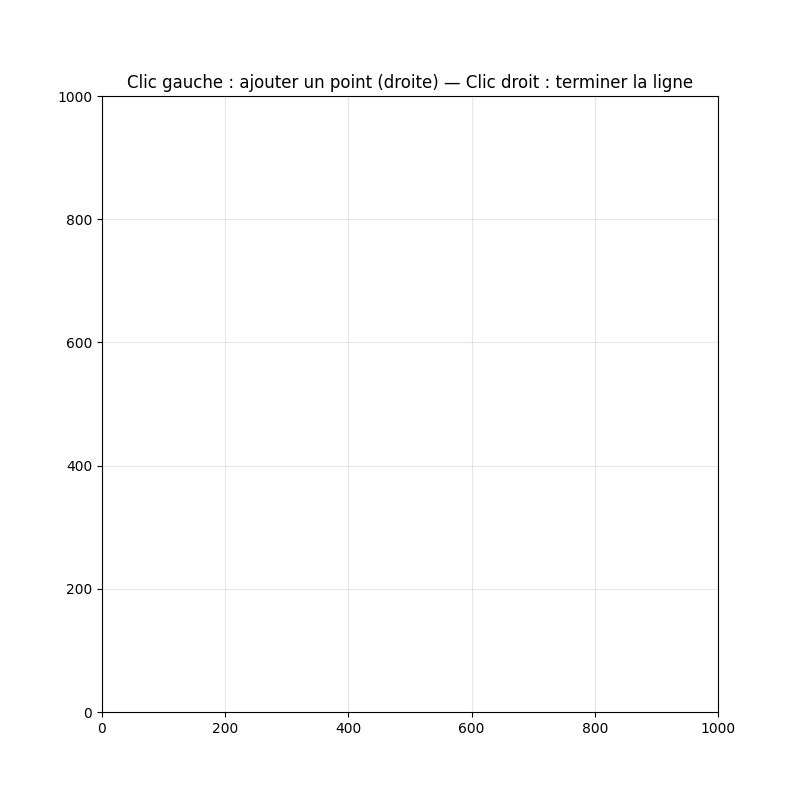

In [5]:
# Création du canevas (étendue 0–1000 en X et Y)
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(0, 1000)
ax.set_ylim(0, 1000)
ax.set_aspect("equal")
ax.set_title("Clic gauche : ajouter un point (droite) — Clic droit : terminer la ligne")
ax.grid(True, alpha=0.3)
cid = fig.canvas.mpl_connect("button_press_event", lambda e: on_click(e, ax, draw_state))
plt.show()

In [6]:
def export_dxf(state, out_path: str, height: float = 1000.0) -> None:
    """Exporte les polylignes en DXF (Y inversé : origine en bas à gauche)."""
    try:
        import ezdxf
    except ImportError:
        raise ImportError("Installer ezdxf : pip install ezdxf")
    doc = ezdxf.new("R2010")
    msp = doc.modelspace()
    for pts in state["polylines"]:
        if len(pts) < 2:
            continue
        pts_dxf = [(float(x), height - float(y)) for x, y in pts]
        msp.add_lwpolyline(pts_dxf, close=False)
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    doc.saveas(out_path)


def export_svg(state, out_path: str) -> None:
    """Exporte les polylignes en SVG (paths)."""
    paths = []
    for pts in state["polylines"]:
        if len(pts) < 2:
            continue
        d = f"M {pts[0][0]:.2f} {pts[0][1]:.2f}"
        for x, y in pts[1:]:
            d += f" L {x:.2f} {y:.2f}"
        paths.append(f'  <path d="{d}" fill="none" stroke="black" stroke-width="2"/>')
    svg = '<?xml version="1.0" encoding="UTF-8"?>\n<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 1000 1000">\n' + "\n".join(paths) + "\n</svg>"
    Path(out_path).write_text(svg, encoding="utf-8")

In [7]:
# Exemple d'export après avoir dessiné (décommenter et exécuter)
# export_dxf(draw_state, "data/mon_dessin.dxf")
# export_svg(draw_state, "data/mon_dessin.svg")